# EmotionSense AI Model Evaluation

Production Model:
emotionsense_best.keras

Current Performance

Test Accuracy : 56%

Note:
This model was selected because it performed better than later fine-tuning experiments.

In [22]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os


from tensorflow.keras.models import load_model

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [23]:
import os

path = "../models/emotionsense_best.keras"

print("Exists :", os.path.exists(path))
print("Absolute:", os.path.abspath(path))
print("Size:", os.path.getsize(path))

Exists : True
Absolute: d:\AI_Projects\EmotionSense_AI\models\emotionsense_best.keras
Size: 32764262


In [24]:
import zipfile
import os

path = "../models/emotionsense_best.keras"

print("Exists:", os.path.exists(path))
print("Size:", os.path.getsize(path))

print("Is ZIP:", zipfile.is_zipfile(path))

if zipfile.is_zipfile(path):
    with zipfile.ZipFile(path, "r") as z:
        print(z.namelist()[:10])

Exists: True
Size: 32764262
Is ZIP: True
['metadata.json', 'config.json', 'model.weights.h5']


In [25]:

from tensorflow.keras.models import load_model

model = load_model("../models/emotionsense_finetuned.keras")

print("✅ Best Model Loaded Successfully!")

✅ Best Model Loaded Successfully!


In [26]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 7,974,522 (30.42 MB)

 Trainable params: 1,795,047 (6.85 MB)

 Non-trainable params: 2,589,379 (9.88 MB)

 Optimizer params: 3,590,096 (13.70 MB)

In [27]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

dataset_path = "../dataset/facial-expression-dataset-image-folders-fer2013/data"

test_dir = os.path.join(dataset_path, "test")

test_datagen = ImageDataGenerator()

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

print("✅ Test Generator Created!")

Found 3589 images belonging to 7 classes.
✅ Test Generator Created!


In [28]:
test_loss, test_accuracy = model.evaluate(
    test_generator,
    verbose=1
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

113/113 ━━━━━━━━━━━━━━━━━━━━ 53s 446ms/step - accuracy: 0.5603 - loss: 1.2186
Test Loss: 1.2186
Test Accuracy: 0.5603


In [29]:
predictions = model.predict(test_generator)

print("Prediction Shape:", predictions.shape)

113/113 ━━━━━━━━━━━━━━━━━━━━ 44s 383ms/step
Prediction Shape: (3589, 7)


In [30]:
y_pred = np.argmax(predictions, axis=1)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[0 0 0 4 4 5 0 2 0 4]


In [31]:
y_true = test_generator.classes

print("First 10 True Labels:")
print(y_true[:10])

First 10 True Labels:
[0 0 0 0 0 0 0 0 0 0]


In [32]:
print("Predicted:", y_pred[:10])
print("Actual   :", y_true[:10])

Predicted: [0 0 0 4 4 5 0 2 0 4]
Actual   : [0 0 0 0 0 0 0 0 0 0]


In [33]:
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix Created!")
print(cm)

Confusion Matrix Created!
[[222   5  37  51  89  15  72]
 [ 17  24   3   3   5   0   3]
 [ 73   2 148  52 119  60  74]
 [ 24   1  25 723  37  17  52]
 [ 67   2  44  66 272  10 133]
 [ 20   0  42  33   8 287  26]
 [ 39   1  36  95 108  12 335]]


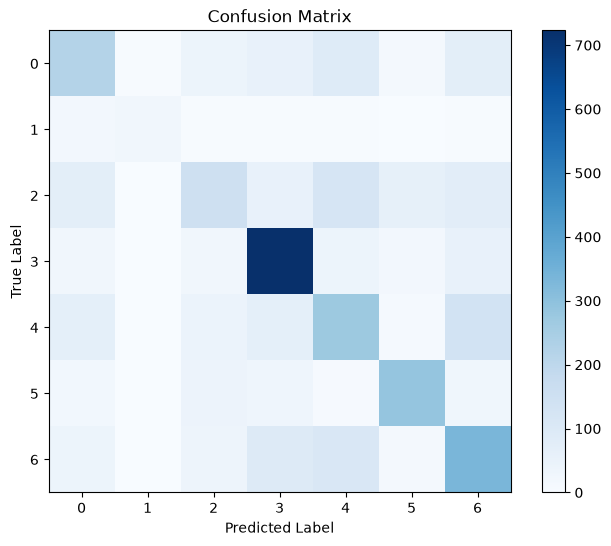

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [35]:
report = classification_report(
    y_true,
    y_pred,
    target_names=test_generator.class_indices.keys()
)

print(report)

              precision    recall  f1-score   support

           0       0.48      0.45      0.47       491
           1       0.69      0.44      0.53        55
           2       0.44      0.28      0.34       528
           3       0.71      0.82      0.76       879
           4       0.43      0.46      0.44       594
           5       0.72      0.69      0.70       416
           6       0.48      0.54      0.51       626

    accuracy                           0.56      3589
   macro avg       0.56      0.52      0.54      3589
weighted avg       0.55      0.56      0.55      3589



In [36]:
dataset_path = "../dataset/facial-expression-dataset-image-folders-fer2013/data"

test_dir = os.path.join(dataset_path, "test")

test_datagen = ImageDataGenerator()

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 3589 images belonging to 7 classes.


In [37]:
print("Class Index Mapping:\n")

for class_name, index in test_generator.class_indices.items():
    print(f"{index} --> {class_name}")

Class Index Mapping:

0 --> 0
1 --> 1
2 --> 2
3 --> 3
4 --> 4
5 --> 5
6 --> 6


In [39]:
import os

model_path = "../models/emotionsense_best.keras"

print("Current Folder :", os.getcwd())
print("Model Path     :", os.path.abspath(model_path))
print("Exists?        :", os.path.exists(model_path))

Current Folder : d:\AI_Projects\EmotionSense_AI\notebooks
Model Path     : d:\AI_Projects\EmotionSense_AI\models\emotionsense_best.keras
Exists?        : True
